# ISFC Greedy Boundary Search Analysis

This notebook uses the Greedy State Boundary Search (GSBS) to find unbiased segmentations of the intersubject cofluctuation of PC activity (i.e., game events shared between agents on the same team). Clustering of these game-state patterns was performed using a Gaussian Mixture Model (GMM)

*Author: Andrew Goldberg*


Table of Contents:
* [Vectorizing Intersubject Cofluctuation Patterns and Running GSBS](#Vectorizing-Intersubject-Cofluctuation-Patterns-and-Running-GSBS)
* [Visualizing ISCFS and GSBS Results](#Visualizing-ISCFS-and-GSBS-Results)
    * [Plot of optimal number of events for GSBS](#Plot-of-optimal-number-of-events-for-GSBS)
    * [Correlation matrix for first 1000 timepoints for test repeat and pair](#Correlation-matrix-for-first-1000-timepoints-for-test-repeat-and-pair)
    * [Correlation matrix for GSBS game-state patterns](#Correlation-matrix-for-GSBS-game--state-patterns)
* [GMM Clustering Analyses](#GMM-Clustering-Analyses)
    * [First Attempt: 30 components, no PCA](#First-Attempt:-30-components,-no-PCA)
    * [Attempt Two: PCA GSBS results first w/ 1000 components, then 30 component GMM](#Attempt-Two:-PCA-GSBS-results-first-w/-1000-components,-then-30-component-GMM)
    * [Based on Results from previous PCA + GMM combo, Run GMM at k = 6 Components](#Based-on-Results-from-previous-PCA-+-GMM-combo,-Run-GMM-at-k-=-6-Components)
* [Miscellaneous Visualizations of GSBS Results and ISFC Results](#Miscellaneous-Visualizations-of-GSBS-Results-and-ISFC-Results)
    * [GMM Cluster Means (for components [0,5]) projected into the 100 by 100 Cofluctuation space](#GMM-Cluster-Means-(for-components-[0,5])-projected-into-the-100-by-100-Cofluctuation-space)
    * [GMM clustering labels for the 2898 GSBS state patterns](#GMM-clustering-labels-for-the-2898-GSBS-state-patterns)
    * [PCA 684 components (90% VAF) and GMM k = 5 Components](#PCA-684-components-(90%-VAF)-and-GMM-k-=-5-Components)
    * [Visualize GMM label results projected back into 4500 timepoint space](#Visualize-GMM-label-results-projected-back-into-4500-timepoint-space)
    
    

In [7]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import scipy.special
from sklearn import manifold
import pickle

import sys
sys.path.insert(0, '/jukebox/hasson/snastase/social-ctf')
from ctf_dataset import load
from ctf_dataset import info
from ctf_dataset.info import constants
from ctf_dataset.info import events
from ctf_dataset.load import virtual
from ctf_dataset.load import utils as load_utils
from scipy.spatial.distance import squareform
from statesegmentation import GSBS

## Vectorizing Intersubject Cofluctuation Patterns and Running GSBS

We first took the cofluctuation matrices with shape (8, 6, 4501, 100, 100) representing (repeats, pairs of agents, timepoints, 100 by 100 PC cofluctuation) and vectorized it for GSBS analysis -> shape (8,6,4501,5050)

GSBS was run only for within-team pairs (i.e., [0,5]) and for all repeats



In [8]:
matchup = 0
k = 100
n_repeats = 8
iscfs = []
for r in np.arange(n_repeats):
    iscf = np.load(f'results/iscf_lstm_tanh-z_pca-k{k}_m{matchup}_r{r}.npy')
    iscfs.append(iscf)
    print(f"Loaded intersubject cofluctuation for repeat {r}")
iscfs = np.array(iscfs)

Loaded intersubject cofluctuation for repeat 0
Loaded intersubject cofluctuation for repeat 1
Loaded intersubject cofluctuation for repeat 2
Loaded intersubject cofluctuation for repeat 3
Loaded intersubject cofluctuation for repeat 4
Loaded intersubject cofluctuation for repeat 5
Loaded intersubject cofluctuation for repeat 6
Loaded intersubject cofluctuation for repeat 7


In [10]:
def vectorize_iscfs(iscfs):
    cf_off = squareform(iscfs,checks = False)
    cf_diag = np.diag(iscfs)
    cf_vec = np.concatenate([cf_off,cf_diag])
    return cf_vec

def square_iscfs(iscfs_vec,ndim=100):
    cf_sq = squareform(iscfs_vec[:-ndim],checks=False)
    cf_diag = iscfs_vec[-ndim:]
    np.fill_diagonal(cf_sq,cf_diag)
    return cf_sq

In [8]:
iscfs.shape

(8, 6, 4501, 100, 100)

In [5]:
cf = iscfs[0,0,0,...] # loop over repeats, pair_id = [0,5], and TP's, save the stacked object of size (5050,4501,6) so you save 8 repeats np.save()'iscfs-vec...'

In [ ]:
n_repeats = 8
n_timepoints = 4501
pair_id = [0,5]
kmax = 300
cf_object = np.zeros((4501,5050))
for t in np.arange(n_timepoints):
    cf_object[t,] = vectorize_iscfs(iscfs[0,0,t,...])
    print(f"Starting for {t}", flush=True)
print(cf_object)

In [ ]:
n_repeats = 8
n_timepoints = 4501
pair_id = [0,5]
kmax = 300

for r in np.arange(n_repeats):
    for pair in pair_id:
        cf_object = np.zeros((4501,5050))
        for t in np.arange(n_timepoints):
            cf_object[t,] = vectorize_iscfs(iscfs[r,pair,t,...])
            
        # cf_object = np.array(cf_object) # needs to be 4500 by 5050
        isfc_gsbs = GSBS(x=cf_object, kmax=kmax) 
        print(f"Starting GSBS for repeat {r}, pair {pair}", flush=True)
        isfc_gsbs.fit()
        np.save(f'results/iscfs-vec-matchup-0_'
        f'repeat-{r}_pair-{pair}_results.npy',cf_object)

        np.save(f'results/gsbs_iscfs-matchup-0_'
        f'repeat-{r}_pair-{pair}_results.npy',
        isfc_gsbs)

Starting GSBS for repeat 0, pair 0


In [ ]:
# Greedy state boundary search
kmax = 300

isfc_gsbs = GSBS(x=cf obj, kmax=kmax) # needs to be 4500 by 5050
print(f"Starting GSBS for matchup {matchup}, repeat {repeat}, pair {pair}",
      flush=True)
start = time()
isfc_gsbs.fit()
print(f"Finished GSBS {(time() - start)/60:.3f} minutes elapsed")

np.save(f'results/gsbs_isfc_win-{width}_matchup-{matchup}_'
        f'repeat-{repeat}_pair-{pair}_results.npy',
        isfc_gsbs)

In [109]:
isfc_gsbs = np.load(f'results/gsbs_z_iscfs-matchup-0_'
f'repeat-0_pair-0_results.npy', allow_pickle=True).item()

## Visualizing ISCFS and GSBS Results



### Plot of optimal number of events for GSBS

**This is only a test image (it's GSBS results one pair and one repeat)**

Most of the GSBS results had around **200** events (out of 300 max based on the total number of seconds in each game)


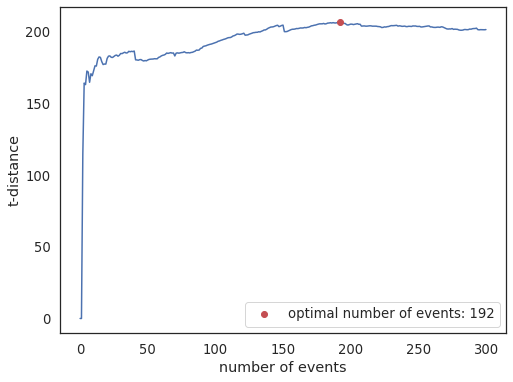

In [13]:
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns


# Plot t-distance for varying number of events
sns.set(font_scale=1.2, style='white')
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(isfc_gsbs.tdists)
ax.set_xlabel(f'number of events')
ax.set_ylabel('t-distance')
ax.plot(isfc_gsbs.nstates,
         isfc_gsbs.tdists[isfc_gsbs.nstates],
         'ro', label=f'optimal number of events: {isfc_gsbs.nstates}')
plt.legend();



### Correlation matrix for first 1000 timepoints for test repeat and pair

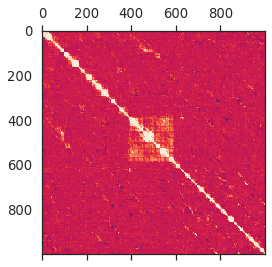

In [117]:
plt.matshow(np.corrcoef(test_cf_vec)[:1000,:1000],vmin=-.2,vmax=.2)

### Correlation matrix binned by GSBS event bounds for same test repeat and pair

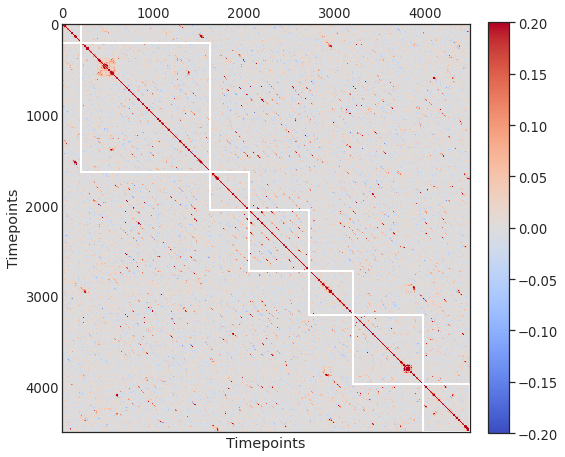

In [113]:
test_cf_vec = np.zeros((4501,5050))
n_timepoints = 4501
for t in np.arange(n_timepoints):
    test_cf_vec[t,] = vectorize_iscfs(iscfs[3,0,t,...])
# Plot event boxes over ISFC matrix
max_dur = 4501

sns.set(font_scale=1.2, style='white')
fig, ax = plt.subplots(figsize=(8, 8))
event_bounds = np.where(isfc_gsbs.bounds)[0]

bounds_aug = np.concatenate(([0], event_bounds, [n_timepoints]))
mat = ax.matshow(np.corrcoef(test_cf_vec)[:max_dur, :max_dur],
                 vmin=-.2, vmax=.2,cmap='coolwarm')
plt.colorbar(mat, fraction=0.046, pad=0.04)
for i in range(len(bounds_aug) - 1):
    rect = patches.Rectangle(
        (bounds_aug[i], bounds_aug[i]),
        bounds_aug[i+1] - bounds_aug[i],
        bounds_aug[i+1] - bounds_aug[i],
        linewidth = 2, edgecolor = 'w',facecolor = 'none'
    )
    ax.add_patch(rect)
plt.tick_params(axis='both', length=0)
plt.xlabel(f'Timepoints')
plt.ylabel(f'Timepoints');

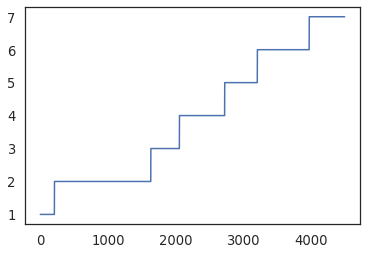

In [118]:
# Plot some discovered states

states = isfc_gsbs.get_states()
plt.plot(states)




### Correlation matrix for GSBS game-state patterns binned by the 8 repeats

Loaded GSBS patterns for matchup 0 repeat 0 pair 0 (300 patterns)
Loaded GSBS patterns for matchup 0 repeat 0 pair 5 (199 patterns)
Loaded GSBS patterns for matchup 0 repeat 1 pair 0 (211 patterns)
Loaded GSBS patterns for matchup 0 repeat 1 pair 5 (194 patterns)
Loaded GSBS patterns for matchup 0 repeat 2 pair 0 (104 patterns)
Loaded GSBS patterns for matchup 0 repeat 2 pair 5 (193 patterns)
Loaded GSBS patterns for matchup 0 repeat 3 pair 0 (174 patterns)
Loaded GSBS patterns for matchup 0 repeat 3 pair 5 (229 patterns)
Loaded GSBS patterns for matchup 0 repeat 4 pair 0 (230 patterns)
Loaded GSBS patterns for matchup 0 repeat 4 pair 5 (169 patterns)
Loaded GSBS patterns for matchup 0 repeat 5 pair 0 (170 patterns)
Loaded GSBS patterns for matchup 0 repeat 5 pair 5 (169 patterns)
Loaded GSBS patterns for matchup 0 repeat 6 pair 0 (14 patterns)
Loaded GSBS patterns for matchup 0 repeat 6 pair 5 (127 patterns)
Loaded GSBS patterns for matchup 0 repeat 7 pair 0 (223 patterns)
Loaded GSBS

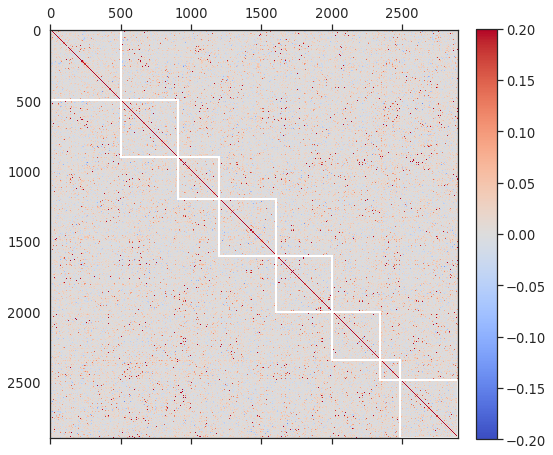

In [14]:
# Load in state patterns across multiple games
coop_ids = (0, 5)
gsbs_patterns, repeat_ids, pair_ids = [], [], []
n_matchups = [0]
for matchup in n_matchups:
    gsbs_stack, repeat_stack, pair_stack = [], [], []
    for repeat in np.arange(n_repeats):
        for pair in coop_ids:
            isfc_gsbs = np.load(f'results/gsbs_iscfs-matchup-0_'
                f'repeat-{repeat}_pair-{pair}_results.npy',allow_pickle=True).item()
            state_patterns = isfc_gsbs.state_patterns
            gsbs_stack.append(state_patterns)
            for p in np.arange(len(state_patterns)):
                repeat_stack.append(repeat)
                pair_stack.append(pair)
            print(f"Loaded GSBS patterns for matchup {matchup} "
                  f"repeat {repeat} pair {pair} "
                  f"({len(isfc_gsbs.state_patterns)} patterns)")
    gsbs_patterns.append(gsbs_stack)
    repeat_ids.append(repeat_stack)
    pair_ids.append(pair_stack)

repeat_bounds = np.concatenate(([0], 
                    np.where(np.diff(repeat_ids[0]) > 0)[0] + 1,
                    [len(repeat_ids[0])]))

sns.set(font_scale=1.2, style='white')
fig, ax = plt.subplots(figsize=(8, 8))
mat = ax.matshow(np.corrcoef(np.vstack(gsbs_patterns[0])),
                 vmin=-.2, vmax=.2,cmap='coolwarm')
plt.colorbar(mat, fraction=0.046, pad=0.04)
for i in range(len(repeat_bounds) - 1):
    rect = patches.Rectangle(
        (repeat_bounds[i], repeat_bounds[i]),
        repeat_bounds[i+1] - repeat_bounds[i],
        repeat_bounds[i+1] - repeat_bounds[i],
        linewidth = 2, edgecolor = 'w',facecolor = 'none'
    )
    ax.add_patch(rect)

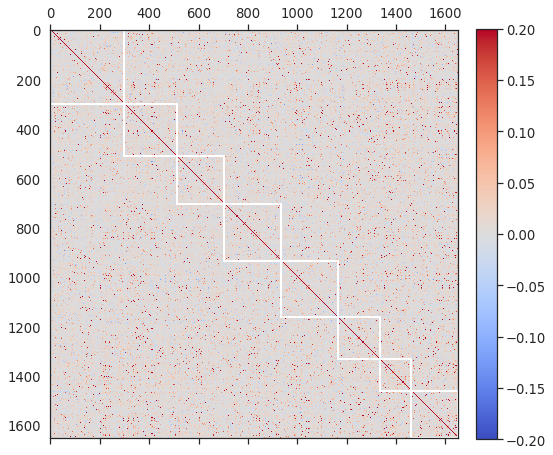

In [56]:
# Split repeated patterns by team color - shown here for team red
matchup = 0
team = 'red'

teams = ['red', 'blue', 'red', 'blue', 'blue', 'red', 'blue', 'red',
         'red', 'blue', 'red', 'blue', 'blue', 'red', 'blue', 'red']
team_ids = np.where(np.array(teams) == team)[0]

gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],
                               dtype='object')[team_ids])

repeat_team = np.concatenate([[r] * len(g) for r, g in 
                    enumerate(np.array(gsbs_patterns[matchup],
                                       dtype='object')[team_ids])])
repeat_bounds = np.concatenate(([0], 
                    np.where(np.diff(repeat_team) > 0)[0] + 1,
                    [len(repeat_team)]))

sns.set(font_scale=1.2, style='white')
fig, ax = plt.subplots(figsize=(8, 8))
mat = ax.matshow(np.corrcoef(gsbs_team),
                 vmin=-.2, vmax=.2,cmap='coolwarm')
plt.colorbar(mat, fraction=0.046, pad=0.04)
for i in range(len(repeat_bounds) - 1):
    rect = patches.Rectangle(
        (repeat_bounds[i], repeat_bounds[i]),
        repeat_bounds[i+1] - repeat_bounds[i],
        repeat_bounds[i+1] - repeat_bounds[i],
        linewidth = 2, edgecolor = 'w',facecolor = 'none'
    )
    ax.add_patch(rect)

## GMM Clustering Analyses

Because the GSBS produced results with ~200 events in each game, it may be the case that similar events are occuring temporally discontiguously - clustering (Gaussian Mixture Model here) can be used to group these game-state patterns in order to identify whether these events really boil down into a few main clusters

### First Attempt: 30 components, no PCA

In [ ]:
# Use Gaussian mixture model to cluster ISFC events
from sklearn.mixture import GaussianMixture

matchup = 0
# team = 'blue'

# team_ids = np.where(np.array(teams) == team)[0]
# gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],
                             #  dtype='object')[team_ids])
gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],
                           dtype='object'))
# gsbs_arctanh = np.arctanh(gsbs_team)

k_grid = np.arange(1, 31)
cov_types = ['spherical', 'tied', 'diag', 'full']
gmm_bic = {'BIC': [], 'AIC': [], 'covariance': [], 'k': []}
for cov_type in cov_types:
    for k in k_grid:
        gmm = GaussianMixture(n_components=k,
                              covariance_type=cov_type)
        gmm.fit(gsbs_team)
        gmm_bic['BIC'].append(gmm.bic(gsbs_team))
        gmm_bic['AIC'].append(gmm.aic(gsbs_team))
        gmm_bic['covariance'].append(cov_type)
        gmm_bic['k'].append(k)
        print(f"Finished {cov_type} GMM with {k} components")

# np.save(f'results/gmm_arctanh_isfc_gsbs_k30_team-{team}_bic.npy',
        # gmm_bic)
np.save(f'results/gmm_arctanh_isfc_gsbs_k30_bic.npy',
    gmm_bic)


/jukebox/hasson/ag42/miniconda3/envs/ctf/lib/python3.7/site-packages/seaborn/categorical.py:3772: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try barplot
  warnings.warn(msg, UserWarning)


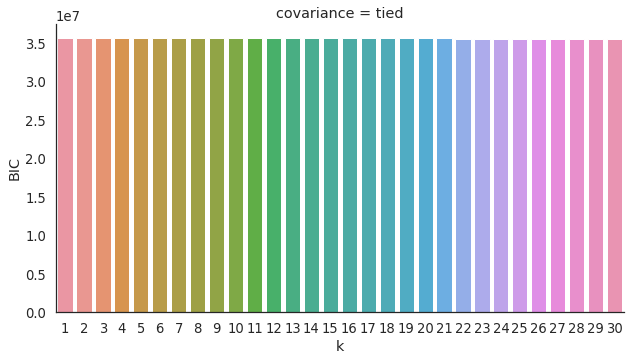

In [85]:
sns.catplot(x='k', y='BIC', col='covariance', kind='bar',
            data=gmm_bic[gmm_bic['covariance'].isin(
                ['tied'])],ax=ax, aspect=1.75)

/jukebox/hasson/ag42/miniconda3/envs/ctf/lib/python3.7/site-packages/seaborn/categorical.py:3772: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try barplot
  warnings.warn(msg, UserWarning)
/jukebox/hasson/ag42/miniconda3/envs/ctf/lib/python3.7/site-packages/seaborn/categorical.py:3772: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try barplot
  warnings.warn(msg, UserWarning)


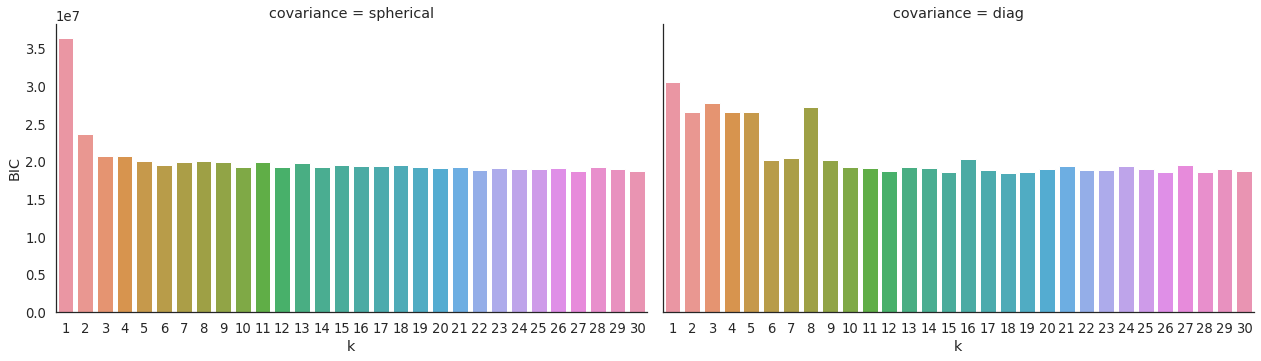

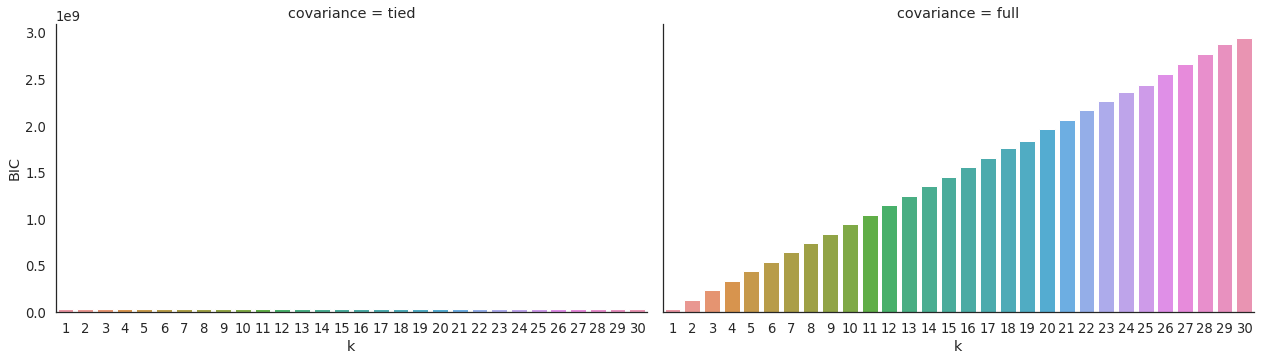

In [75]:
import pandas as pd
gmm_bic = np.load('results/gmm_arctanh_isfc_gsbs_k30_bic.npy',
                   allow_pickle=True).item()
gmm_bic = pd.DataFrame(gmm_bic)

sns.catplot(x='k', y='BIC', col='covariance', kind='bar',
            data=gmm_bic[gmm_bic['covariance'].isin(
                ['spherical', 'diag'])], ax=ax, aspect=1.75)
sns.catplot(x='k', y='BIC', col='covariance', kind='bar',
            data=gmm_bic[gmm_bic['covariance'].isin(
                ['full', 'tied'])], ax=ax, aspect=1.75)

### Attempt Two: PCA GSBS results first w/ 1000 components, then 30 component GMM

The results from the first analysis weren't very conclusive so we wanted to see what would happen if we first PCA'ed the GSBS results and then ran the GMM

In [96]:
# PCA to reduce dimensionality of ISFC events
from sklearn.decomposition import PCA

n_matchups = [0]
# team = 'blue'    
percents = [.5, .75, .9, .95, .99, 1.0]
gsbs_reduced = []
gsbs_vaf = []
for matchup in n_matchups:

    # team_ids = np.where(np.array(teams) == team)[0]
    gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],
                               dtype='object'))
    # gsbs_arctanh = np.arctanh(gsbs_team)

    k = 1000

    pca = PCA(n_components=k)
    gsbs_reduced.append(pca.fit_transform(gsbs_team))
    print(f"\nApplied PCA to ISFC events for matchup {matchup}")
    vaf_dims = {}
    for percent in percents:
        n_dims = np.sum(np.cumsum(pca.explained_variance_ratio_)
                        <= percent)
        vaf_dims[percent] = n_dims
        print(f"{percent:.0%} variance accoounted for: "
              f"{n_dims} components")
    gsbs_vaf.append(vaf_dims)



Applied PCA to ISFC events for matchup 0
50% variance accoounted for: 3 components
75% variance accoounted for: 184 components
90% variance accoounted for: 684 components
95% variance accoounted for: 1000 components
99% variance accoounted for: 1000 components
100% variance accoounted for: 1000 components


In [ ]:
# Run GMM on PCA-reduced ISFC events
matchup = 0

k_grid = np.arange(1, 31)
cov_types = ['spherical', 'tied', 'diag', 'full']
gmm_bic = {'BIC': [], 'AIC': [], 'covariance': [],
           'k': [], 'PCA VAF': []}
percents = [.5, .75, .9, .95, .99, 1.0]
for percent in percents:
    for cov_type in cov_types:
        for k in k_grid:
            gsbs_trunc = gsbs_reduced[matchup][
                :, :gsbs_vaf[matchup][percent]]
            gmm = GaussianMixture(n_components=k,
                                  covariance_type=cov_type)
            gmm.fit(gsbs_trunc)
            gmm_bic['BIC'].append(gmm.bic(gsbs_trunc))
            gmm_bic['AIC'].append(gmm.aic(gsbs_trunc))
            gmm_bic['covariance'].append(cov_type)
            gmm_bic['k'].append(k)
            gmm_bic['PCA VAF'].append(percent)
            print(f"Finished {cov_type} GMM at {percent:.0%} VAF "
                  f"({gsbs_vaf[matchup][percent]} dimensions "
                  f"with {k} components")

np.save(f'results/gmm_pca-arctanh_isfc_gsbs_k30_bic.npy',
        gmm_bic)

In [ ]:
gmm_bic[(gmm_bic['PCA VAF'] == .90) &
                    (gmm_bic['covariance'] ==)]

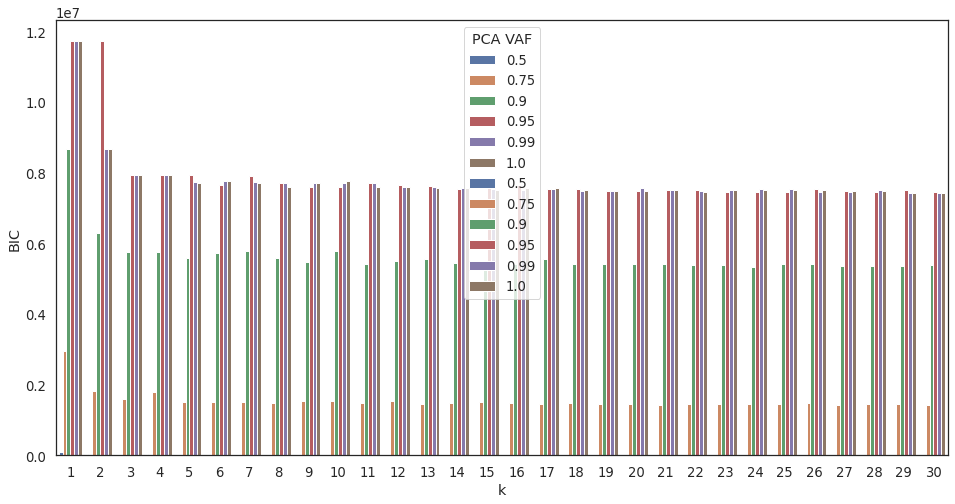

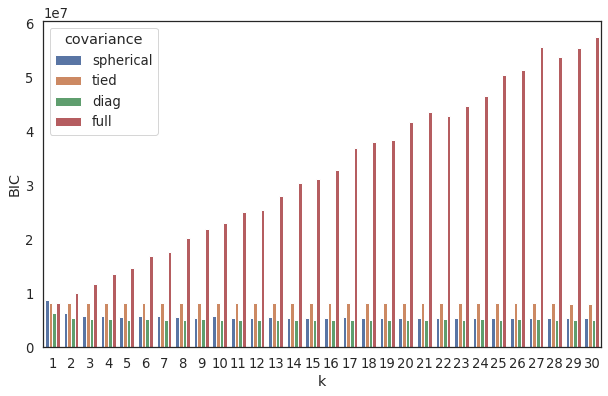

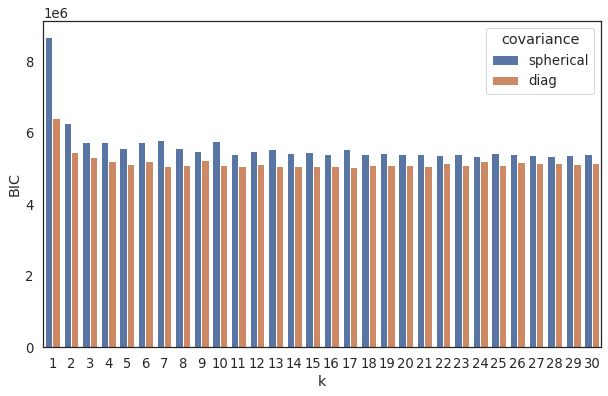

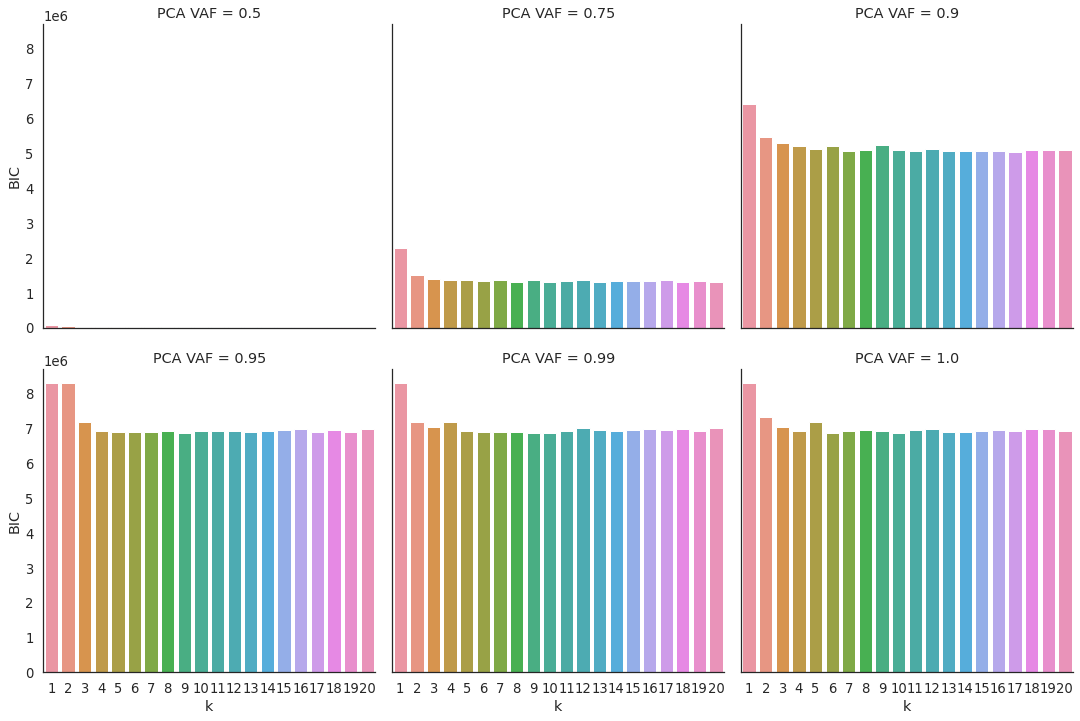

In [124]:
gmm_bic = np.load('results/gmm_pca-arctanh_isfc_gsbs_k30_bic.npy',
                   allow_pickle=True).item()
gmm_bic = pd.DataFrame(gmm_bic)
gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'diag')]
#gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'spherical') &
                    #(gmm_bic['PCA VAF'] == .75)]
fig, ax = plt.subplots(figsize=(16,8))

sns.barplot(x='k', y='BIC', ax=ax, data=gmm_trunc,hue = gmm_bic['PCA VAF'])

gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'spherical')]
sns.barplot(x='k', y='BIC', hue='PCA VAF',
            data=gmm_trunc)

fig, ax = plt.subplots(figsize=(10, 6))
gmm_trunc = gmm_bic[(gmm_bic['PCA VAF'] == .90)]
sns.barplot(x='k', y='BIC', hue='covariance',
            data=gmm_trunc, ax=ax)

cov_types = ['spherical', 'diag']
fig, ax = plt.subplots(figsize=(10, 6))
gmm_trunc = gmm_bic[(gmm_bic['PCA VAF'] == .90) &
                    (gmm_bic['covariance'].isin(cov_types))]
sns.barplot(x='k', y='BIC', hue='covariance',
            data=gmm_trunc, ax=ax)

gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'diag') &
                    (gmm_bic['k'] <= 20)]
sns.catplot(x='k', y='BIC', col='PCA VAF', col_wrap=3,
            data=gmm_trunc, kind='bar')

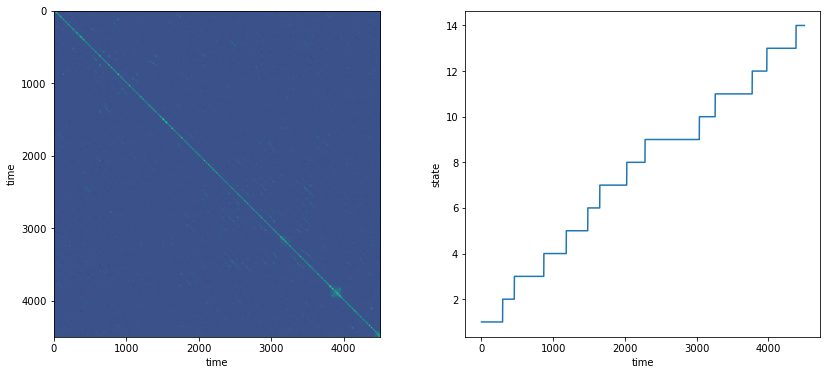

In [30]:
test_cf_vec = np.zeros((4501,5050))
n_timepoints = 4501
for t in np.arange(n_timepoints):
            test_cf_vec[t,] = vectorize_iscfs(iscfs[6,0,t,...])
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
ax1.imshow(np.corrcoef(test_cf_vec))
ax1.set_xlabel('time')
ax1.set_ylabel('time')
ax2.plot(test_load.states)
ax2.set_ylabel('state')
ax2.set_xlabel('time')
plt.show()

In [104]:
n_repeats = 8
n_pairs = 6

states_vec = np.zeros((n_repeats,n_pairs))
for r in np.arange(n_repeats):
    for pair in np.arange(n_pairs):
        test_load = np.load(f'results/gsbs_z_iscfs-matchup-0_'
        f'repeat-{r}_pair-{pair}_results.npy', allow_pickle=True).item()
        states_vec[r,pair] = test_load.states[-1]
        print(f"loaded repeat {r}, pair {pair})

In [9]:
n_timepoints = 4501
test_cf_vec = np.zeros((4501,5050))
for t in np.arange(n_timepoints):
            test_cf_vec[t,] = vectorize_iscfs(iscfs[0,5,t,...])
from scipy.stats import zscore
cf_vecs = zscore(test_cf_vec,axis=0)

### Based on Results from previous PCA + GMM combo, Run GMM at k = 5 Components

5 components seemed reasonable based off the results for PCA + 30 GMM components in terms of the BIC results (slight uptick in BIC for 6 components) - so GMM was run at 5 components do some further analyses

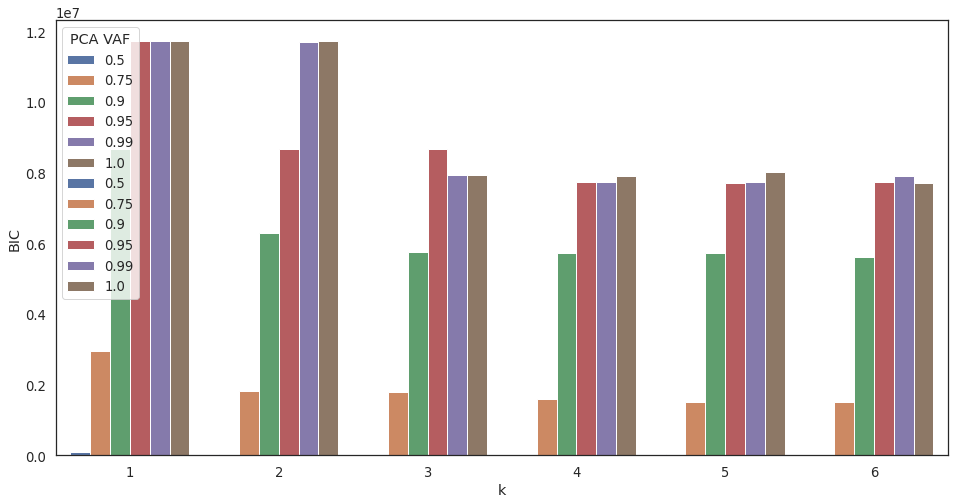

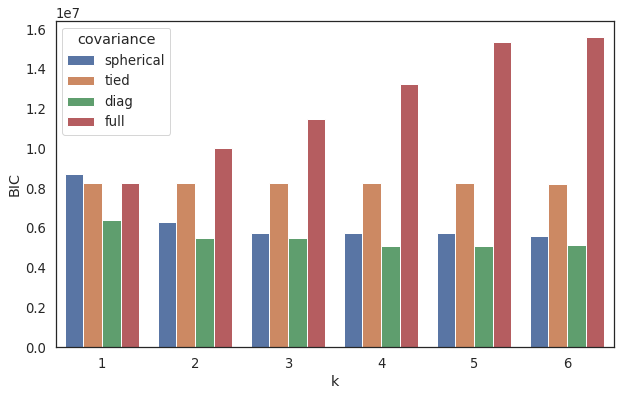

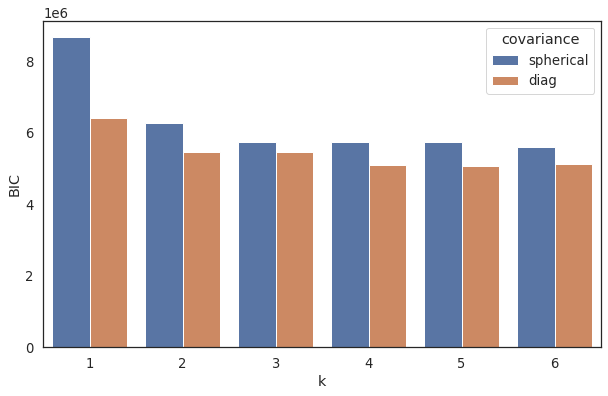

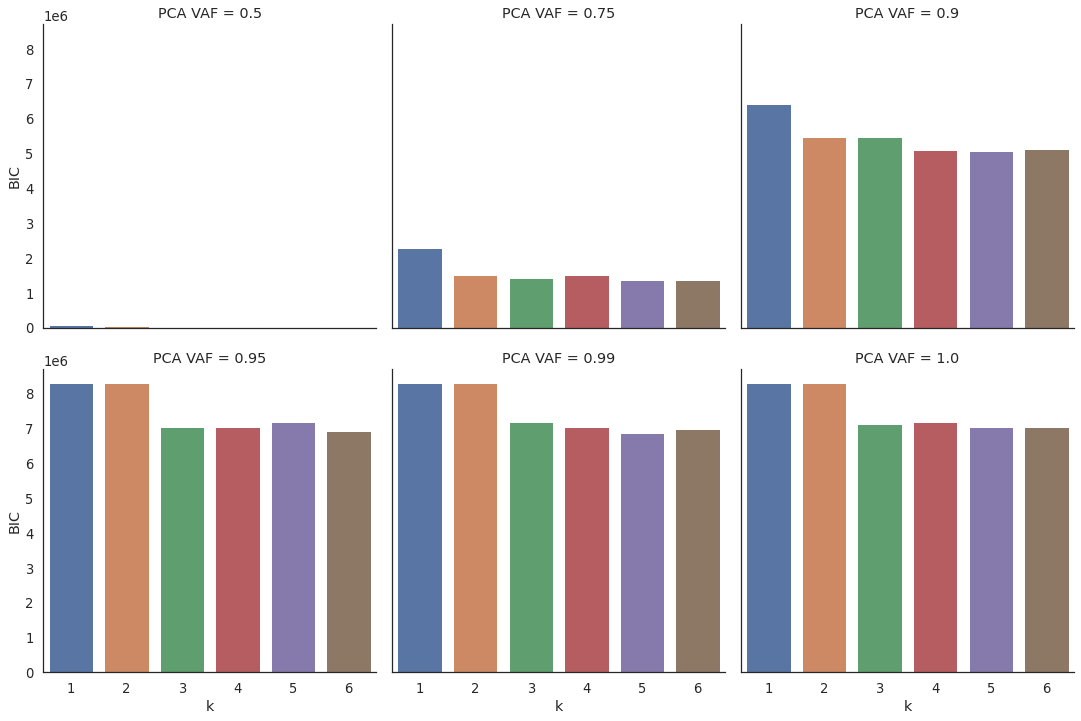

In [131]:
gmm_bic = np.load('results/gmm_pca-arctanh_isfc_gsbs_k6_bic.npy',
                   allow_pickle=True).item()
gmm_bic = pd.DataFrame(gmm_bic)
gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'diag')]
#gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'spherical') &
                    #(gmm_bic['PCA VAF'] == .75)]
fig, ax = plt.subplots(figsize=(16,8))

sns.barplot(x='k', y='BIC', ax=ax, data=gmm_trunc,hue = gmm_bic['PCA VAF'])

gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'spherical')]
sns.barplot(x='k', y='BIC', hue='PCA VAF',
            data=gmm_trunc)

fig, ax = plt.subplots(figsize=(10, 6))
gmm_trunc = gmm_bic[(gmm_bic['PCA VAF'] == .90)]
sns.barplot(x='k', y='BIC', hue='covariance',
            data=gmm_trunc, ax=ax)

cov_types = ['spherical', 'diag']
fig, ax = plt.subplots(figsize=(10, 6))
gmm_trunc = gmm_bic[(gmm_bic['PCA VAF'] == .90) &
                    (gmm_bic['covariance'].isin(cov_types))]
sns.barplot(x='k', y='BIC', hue='covariance',
            data=gmm_trunc, ax=ax)

gmm_trunc = gmm_bic[(gmm_bic['covariance'] == 'diag') &
                    (gmm_bic['k'] <= 20)]
sns.catplot(x='k', y='BIC', col='PCA VAF', col_wrap=3,
            data=gmm_trunc, kind='bar')

In [82]:
# run at 90% VAF with score
from sklearn.decomposition import PCA

n_matchups = [0]   
percents = [.5, .75, .9, .95, .99, 1.0]
gsbs_reduced_90 = []
for matchup in n_matchups:
    # team_ids = np.where(np.array(teams) == team)[0]
    gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],dtype='object'))
    # gsbs_arctanh = np.arctanh(gsbs_team)

    k = 684

    pca_90 = PCA(n_components=k)
    gsbs_reduced_90.append(pca_90.fit_transform(zscore(gsbs_team,axis=0)))
    # 90% VAF (684 components) & k = 5 GMM components
    # PCA to reduce dimensionality of ISFC events
    k = 5
    gsbs_trunc = gsbs_reduced_90[matchup]
    gmm_90 = GaussianMixture(n_components=k,
                          covariance_type='diag')
    gmm_90.fit(gsbs_trunc)

np.save(f'results/gmm_pca-arctanh_isfc_gsbs_k5_bic.npy',gmm_90)

## Miscellaneous Visualizations of GSBS Results and ISFC Results

### GMM Cluster Means (for components [0,4]) projected into the 100 by 100 Cofluctuation space 

Using pca.inverse_transform (from the PCA used for the GSBS data) the GMM cluster means were projected and then visualized as an ISFC matrix. Real example ISFC Matrix shown under

In [69]:
reverse_pca = pca_90.inverse_transform(gmm_90.means_)

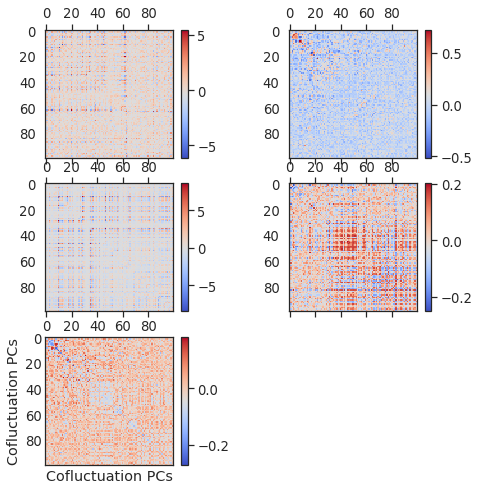

In [80]:
# compare inverse transformed PCA against ISFC matrix

sns.set(font_scale=1.2, style='white')
fig, axs = plt.subplots(3,2,figsize=(8, 8))
fig.delaxes(axs[2,1])
square_reverse_pca = [square_iscfs(r) for r in reverse_pca]
for s,ax in zip(square_reverse_pca,axs.ravel()):        
    mat = ax.matshow(s, cmap='coolwarm')
    plt.colorbar(mat, ax=ax, fraction=0.046, pad=0.04)
    plt.tick_params(axis='both', length=0)
    plt.xlabel(f'Cofluctuation PCs')
    plt.ylabel(f'Cofluctuation PCs')
    


### 

**Example for a given pair and repeat ISFC Matrix from the original Cofluctuation data**

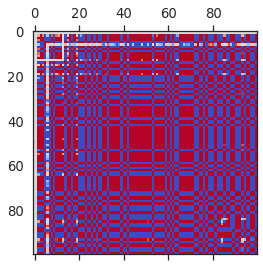

In [93]:
cf = iscfs[0,0,0,...]
plt.matshow(cf, vmin=-.2, vmax=.2,cmap='coolwarm')

### GMM clustering labels for the 2898 GSBS state patterns  

Based on the GMM clusters, give a cluster label to each of the 2898 game-states found by  GSBS 

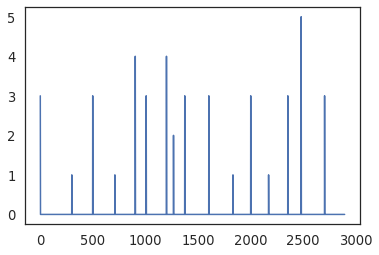

In [423]:
plt.plot(labels.T)

In [290]:
k = 5
gmm = GaussianMixture(n_components=k, covariance_type='diag')
labels_fp = gmm.fit_predict(gsbs_reduced[0][:,:684])

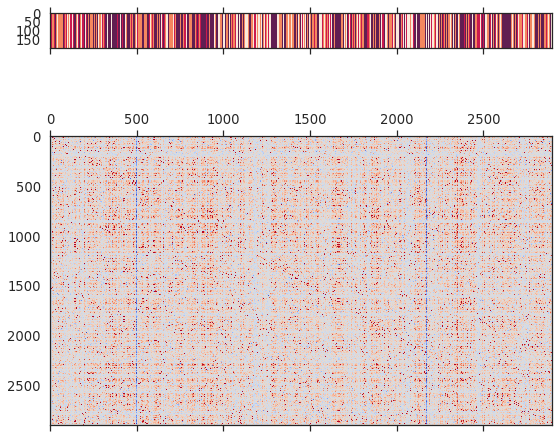

In [311]:
sns.set(font_scale=1.2, style='white')
fig, axs = plt.subplots(2,1,figsize=(8, 8),sharex=True)
axs[0].matshow(np.repeat(labels_fp[:,np.newaxis],200,axis=1).T)

mat = axs[1].matshow(np.corrcoef(np.vstack(gsbs_reduced[0][:,:684])),
                 vmin=-.2, vmax=.2,cmap='coolwarm')
axs[1].set_aspect('auto')
plt.tight_layout()
# plt.colorbar(mat, fraction=0.046, pad=0.04)




### PCA 684 components (90% VAF) and GMM k = 5 Components

In [65]:
# run at 90% VAF with score
from sklearn.decomposition import PCA

n_matchups = [0]   
percents = [.5, .75, .9, .95, .99, 1.0]
gsbs_reduced_90 = []
for matchup in n_matchups:
    # team_ids = np.where(np.array(teams) == team)[0]
    gsbs_team = np.vstack(np.array(gsbs_patterns[matchup],dtype='object'))
    # gsbs_arctanh = np.arctanh(gsbs_team)

    k = 684

    pca_90 = PCA(n_components=k)
    gsbs_reduced_90.append(pca_90.fit_transform(zscore(gsbs_team,axis=0)))
    # 90% VAF (684 components) & k = 5 GMM components
    # PCA to reduce dimensionality of ISFC events
    k = 5
    gsbs_trunc = gsbs_reduced_90[matchup]
    gmm_90 = GaussianMixture(n_components=k,
                          covariance_type='diag')
    gmm_90.fit(gsbs_trunc)

# np.save(f'results/gmm_pca-arctanh_isfc_gsbs_k6_bic.npy',gmm_bic)

### Visualize GMM label results projected back into 4500 timepoint space

Take the isfc object for each pair/repeat (4500 timepoints, 5500 vectorized cofluctuation data) and apply the pca used on the GSBS data to get it down to (4500 timepoints, k = 684 components). Then use the .predict() method from the fitted GMM object to give each timepoint a label and visualize

*visualized only for the first pair and repeat - you would have 16 of these total (8 repeats * 2 pairs each)*
**also note that one of the cluster is degenerate - this seems to be a common trend across GMM results and requires careful consideration**

In [31]:
# rerun gmm
# keep in mind when you're looping through the gmm fititng step, it keeps getting refit
# so re run once at the end to get the one you want

count = 0
pair_id = [0,5]
n_timepoints = 4501
predict = np.zeros((n_timepoints,n_repeats*2))
for r in np.arange(n_repeats):
    for pair in pair_id:
        iscfs_object = np.zeros((4501,5050))
        for t in np.arange(n_timepoints):
            iscfs_object[t,] = vectorize_iscfs(iscfs[r,pair,t,...])
        
        iscfs_pca = pca_90.transform(iscfs_object)
        predict[:,count] = gmm_90.predict(iscfs_pca[:,:684])
        count = count + 1
        

In [ ]:
np.unique(predict)

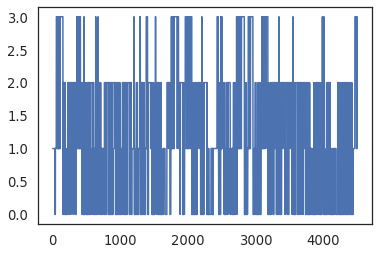

In [399]:
plt.plot(predict[:,0])

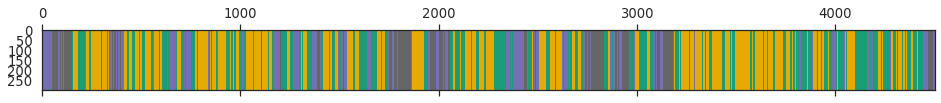

In [410]:
plt.matshow(np.repeat(predict[:,0][:,np.newaxis],300,axis=1).T,cmap='Dark2')

In [412]:
predict_expand = np.full((4,4501),np.nan)
for i,p in enumerate(predict[:,0]):
    predict_expand[int(p),i] = p

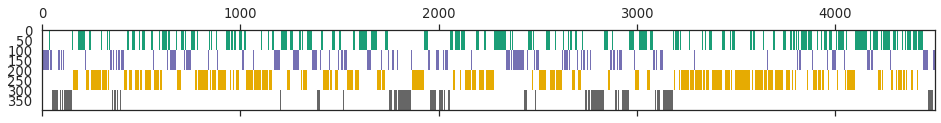

In [417]:
plt.matshow(np.repeat(predict_expand,100,axis=0),cmap='Dark2')

### Correlate labels with a few in-game behaviors

In [55]:
from os.path import join
from scipy.stats import pearsonr, zscore
from statistical_tests import (fisher_mean, block_iscf, 
                               block_randomization)
from ctf_dataset.load import create_wrapped_dataset

# Import behavior heuristics
from ctf_dataset.behaviours.heuristic import (
                                              near_teammate,
                                              camp_own_base,
                                              camp_opponent_base,
                                              approaching_teammate)
                                          
# Set base directory 
base_dir = '/jukebox/hasson/snastase/social-ctf'
data_dir = join(base_dir, 'data')

# Create wrapped CTF dataset
wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")

map_id = 0 # 0
matchup_id = 0 # 0-54 (0, 34, 49, 54)
repeat_id = slice(None) # 0-7
player_id = slice(None) # 0-3



# Compute near teammate behavior time series (symmetric)
nears = near_teammate(wrap_f, map_id=map_id, matchup_id=matchup_id,
                      repeat_id=slice(None), player_id=slice(None),
                      min_behaviour_length=15, teammate_radius=3).squeeze()


# Compute base-camping behavior time series (symmetric)
approachs = approaching_teammate(wrap_f, map_id=map_id,
                                 matchup_id=matchup_id,
                                 repeat_id=slice(None),
                                 player_id=slice(None),
                                 min_behaviour_length=15,
                                 min_approach=.5).squeeze()

# Compute base-camping behavior time series (asymmetric)
basecamps = camp_own_base(wrap_f, map_id=map_id, matchup_id=matchup_id,
                          repeat_id=slice(None), player_id=slice(None),
                          min_behaviour_length=15,
                          base_radius=3).squeeze()

# Compute base-camping behavior time series (asymmetric)
spawncamps = camp_opponent_base(wrap_f, map_id=map_id,
                                matchup_id=matchup_id,
                                repeat_id=slice(None),
                                player_id=slice(None),
                                min_behaviour_length=15,
                                base_radius=3).squeeze()

In [56]:
n_agents = nears.shape[1]
n_timeseries = predict.shape[1]
corr_coef = np.zeros((n_timeseries,n_agents))

for num in np.arange(n_timeseries):
    for agent in np.arange(n_agents):
        corr_coef[num,agent] = pearsonr(predict[:,num],nears[int(np.floor(num/2)),agent,:])[0]      
print(corr_coef)

[[ 0.01944452  0.01944452  0.06053275  0.06053275]
 [ 0.08214943  0.08214943 -0.03853847 -0.03853847]
 [-0.12710225 -0.12710225  0.05487106  0.05487106]
 [ 0.0423234   0.0423234  -0.05692883 -0.05692883]
 [-0.08841826 -0.08841826 -0.02480651 -0.02480651]
 [ 0.03990695  0.03990695 -0.04629168 -0.04629168]
 [-0.06885571 -0.06885571 -0.01285131 -0.01285131]
 [ 0.01926817  0.01926817 -0.08148019 -0.08148019]
 [-0.08100682 -0.08100682  0.10820138  0.10820138]
 [ 0.0355352   0.0355352  -0.04675917 -0.04675917]
 [ 0.02525464  0.02525464 -0.0191669  -0.0191669 ]
 [ 0.17459477  0.17459477 -0.00252578 -0.00252578]
 [-0.12105552 -0.12105552  0.02431991  0.02431991]
 [ 0.0118264   0.0118264  -0.12541667 -0.12541667]
 [-0.08467401 -0.08467401  0.03593073  0.03593073]
 [ 0.03954133  0.03954133 -0.0186573  -0.0186573 ]]


In [57]:
n_agents = nears.shape[1]
n_timeseries = predict.shape[1]
corr_coef = np.zeros((n_timeseries,n_agents))

for num in np.arange(n_timeseries):
    for agent in np.arange(n_agents):
        corr_coef[num,agent] = pearsonr(predict[:,num],approachs[int(np.floor(num/2)),agent,:])[0]      
print(corr_coef)

[[ 0.01661382  0.01661382 -0.08936772 -0.08936772]
 [-0.03356674 -0.03356674 -0.09431332 -0.09431332]
 [-0.00736343 -0.00736343 -0.05129432 -0.05129432]
 [-0.01885517 -0.01885517 -0.00393718 -0.00393718]
 [-0.06166096 -0.06166096  0.05823565  0.05823565]
 [-0.01424258 -0.01424258 -0.0585743  -0.0585743 ]
 [-0.1000136  -0.1000136  -0.01949398 -0.01949398]
 [-0.05568541 -0.05568541 -0.03084311 -0.03084311]
 [-0.10115991 -0.10115991 -0.05570567 -0.05570567]
 [-0.0626138  -0.0626138   0.00184533  0.00184533]
 [ 0.01295621  0.01295621 -0.07190226 -0.07190226]
 [-0.0632303  -0.0632303  -0.02281813 -0.02281813]
 [-0.10296597 -0.10296597 -0.08174505 -0.08174505]
 [-0.01190846 -0.01190846 -0.06924506 -0.06924506]
 [ 0.02726548  0.02726548 -0.08568494 -0.08568494]
 [ 0.0614818   0.0614818  -0.03396093 -0.03396093]]


In [58]:
n_agents = nears.shape[1]
n_timeseries = predict.shape[1]
corr_coef = np.zeros((n_timeseries,n_agents))

for num in np.arange(n_timeseries):
    for agent in np.arange(n_agents):
        corr_coef[num,agent] = pearsonr(predict[:,num],basecamps[int(np.floor(num/2)),agent,:])[0]      
print(corr_coef)

[[ 1.29000134e-02 -1.85570251e-02  6.43134586e-02 -3.87851431e-05]
 [-1.42651948e-02 -2.77541803e-02 -4.29221684e-02 -9.33138092e-03]
 [ 5.05324417e-02 -2.93760365e-02  2.03764107e-02  2.69114130e-03]
 [-2.77515956e-03 -2.02705502e-04  1.66215043e-02 -1.42125669e-02]
 [-4.32144989e-02 -1.29020488e-02 -5.10485720e-02 -2.48890250e-02]
 [ 6.01773831e-02 -8.03434422e-02 -3.51290835e-02 -1.49323986e-02]
 [-2.84976643e-02 -2.74365307e-02 -4.50814204e-02  1.12456387e-02]
 [ 2.19150628e-02 -1.32538557e-02 -4.92295822e-02 -5.54010448e-02]
 [-2.48547258e-02 -6.96961973e-02  5.97885565e-04 -4.20054424e-02]
 [-8.26482265e-02 -1.01617730e-02  5.22337611e-02 -2.84145751e-02]
 [ 2.34183495e-02 -4.46320823e-02  1.64209366e-02  1.59752364e-02]
 [-2.86501923e-02 -6.41638771e-02  4.79454943e-02  1.53619784e-02]
 [ 1.98957528e-02 -1.81942646e-02 -5.20450142e-02 -1.45275722e-02]
 [ 4.74617050e-02  5.38156653e-03 -3.68256105e-02 -2.36015082e-02]
 [ 7.48858440e-02  1.96088536e-02 -5.31926674e-02 -2.94396817e

In [59]:
n_agents = nears.shape[1]
n_timeseries = predict.shape[1]
corr_coef = np.zeros((n_timeseries,n_agents))

for num in np.arange(n_timeseries):
    for agent in np.arange(n_agents):
        corr_coef[num,agent] = pearsonr(predict[:,num],spawncamps[int(np.floor(num/2)),agent,:])[0]      
print(corr_coef)

[[ 0.04124176  0.04791687  0.02663809  0.03955915]
 [ 0.00838094  0.02445463  0.00743386  0.02794595]
 [ 0.03835137  0.01245353 -0.02389128  0.01100701]
 [ 0.0082265   0.00220304  0.02405599  0.04879459]
 [ 0.00578237 -0.01093614 -0.02953474 -0.03081073]
 [-0.02254471 -0.05552768  0.00364303 -0.03912666]
 [ 0.01916688 -0.01146904 -0.08423752 -0.03702497]
 [ 0.00132837 -0.0529543  -0.02476009  0.02001499]
 [-0.02501027 -0.01476669 -0.00470527 -0.01898239]
 [-0.02793246 -0.06982173  0.04168681  0.01043373]
 [ 0.01533984  0.00430979  0.01812854 -0.03587956]
 [ 0.00340357 -0.04477608 -0.04105201 -0.04856532]
 [-0.08766832 -0.05038098 -0.03662017 -0.12547534]
 [-0.04966583 -0.05274546 -0.00022642 -0.02716975]
 [ 0.0282541   0.02002093 -0.04129303 -0.01191215]
 [-0.04153194  0.04714729  0.00271825  0.01534578]]


In [ ]:
# fix toc
# remove 6 components  - should we get stats version for k = 5 or is it fine?